. What is Linear Regression?

Linear Regression is a supervised machine learning algorithm used to predict a continuous numerical value by finding the best linear relationship between one or more input features and a target variable.

Examples:

    House price prediction
    Salary prediction
    Temperature prediction
    Waste price prediction

3. Goal

    Find the best line that fits the data.



In [1]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
#This is the dataset that i will work with 
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing(as_frame=True)

df = housing.frame

#Explore the data
df.head()
df.describe()
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

In [ ]:
#Split 
X = df.drop("MedHouseVal", axis=1)
y = df["MedHouseVal"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

#Fit the model

model = LinearRegression()

model.fit(X_train, y_train)

#Prediction 
y_pred = model.predict(X_test)

comparison = pd.DataFrame({
    "Actual": y_test,
    "Prediction": y_pred
})

#Compare
comparison.head(10)
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 0.5332001304956555
MSE : 0.5558915986952442
RMSE: 0.7455813830127763
R²  : 0.575787706032451


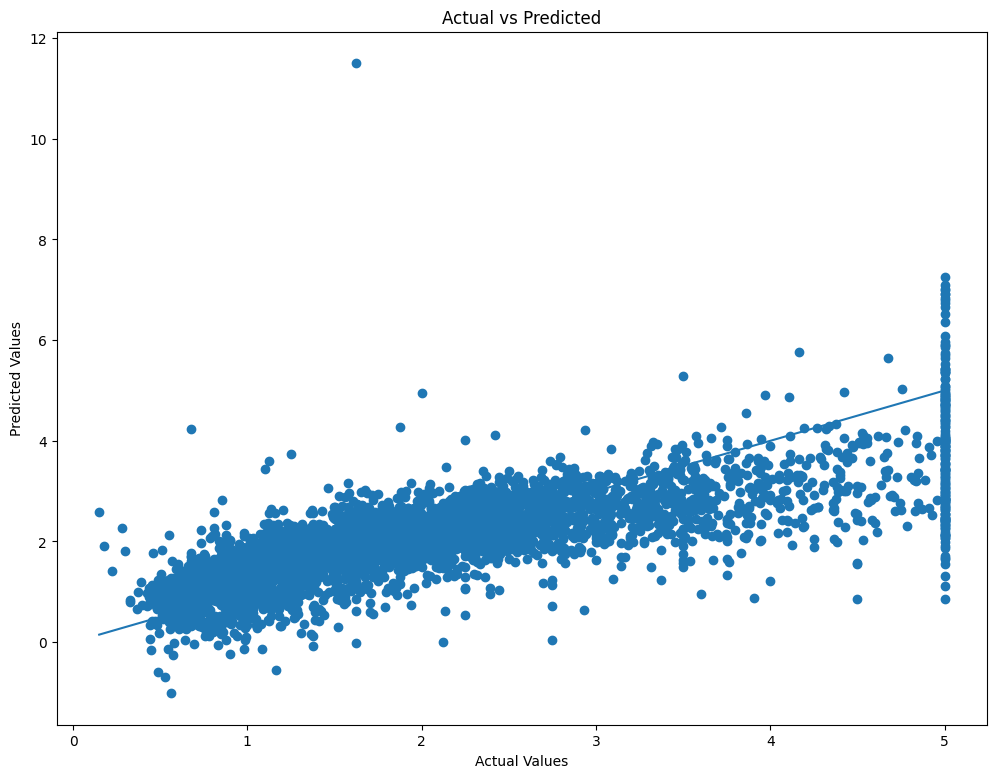

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,9))

plt.scatter(y_test, y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted")

plt.show()